In [ ]:
!pip install pymatgen mp-api umap-learn imbalanced-learn scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 6.1 MB/s eta 0:00:00
  

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE

In [ ]:
# ============================================================================
# CONFIGURATION & SETUP
# ============================================================================

API_KEY = "sMWxUUzNkgFJyEegqotWyVYFJEtK4N7K"
TARGET_SYSTEMS = ["cubic", "monoclinic", "orthorhombic", "tetragonal"]

TWO_THETA_MIN = 10
TWO_THETA_MAX = 110
N_POINTS = 2048
MAX_PER_CLASS = 50000

SEED = 15
EPOCHS_FINAL = 10
BATCH_SIZE = 16

# Set seed for reproducibility
def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")
print(f"Target crystal systems: {TARGET_SYSTEMS}")
print(f"Data Split Ratio - Training:Validation:Testing = 70:10:20")
print(f"Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print(f"Oversampling Method: SMOTE (Standard)")
print(f"Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:20%:20%")

Seed set to 15
Target crystal systems: ['cubic', 'monoclinic', 'orthorhombic', 'tetragonal']
Data Split Ratio - Training:Validation:Testing = 70:10:20
Epochs: 10 (NO Early Stopping)
Oversampling Method: SMOTE (Standard)
Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:20%:20%


In [ ]:
# ============================================================================
# DATA LOADING FROM MATERIALS PROJECT
# ============================================================================

def load_perovskite_data_from_mp(api_key: str, max_per_class: int = MAX_PER_CLASS):
    """Load perovskite data from Materials Project"""

    data_records = []
    class_counts = {c: 0 for c in TARGET_SYSTEMS}

    with MPRester(api_key) as mpr:
        # Search for perovskite materials
        robo_docs = mpr.materials.robocrys.search(keywords=["perovskite"])
        perov_mpids = [str(doc.material_id) for doc in robo_docs][:50000]

        print(f"Found {len(perov_mpids)} perovskite materials")

        # Get material summaries
        summaries = mpr.materials.summary.search(
            material_ids=perov_mpids,
            fields=["material_id", "structure", "symmetry", "formula_pretty",
                   "density", "volume", "nsites"],
        )

        for doc in summaries:
            sym = getattr(doc, "symmetry", None)
            if sym is None or sym.crystal_system is None:
                continue

            cs_raw = sym.crystal_system
            if hasattr(cs_raw, "value"):
                cs = str(cs_raw.value).lower()
            else:
                cs_str = str(cs_raw)
                if "." in cs_str:
                    cs_str = cs_str.split(".")[-1]
                cs = cs_str.lower()

            if cs not in TARGET_SYSTEMS:
                continue
            if class_counts[cs] >= max_per_class:
                continue

            structure = doc.structure
            if structure is None:
                continue

            # Collect data
            record = {
                'material_id': str(doc.material_id),
                'formula': str(doc.formula_pretty) if hasattr(doc, 'formula_pretty') else None,
                'crystal_system': cs,
                'density': float(doc.density) if hasattr(doc, 'density') else None,
                'volume': float(doc.volume) if hasattr(doc, 'volume') else None,
                'nsites': int(doc.nsites) if hasattr(doc, 'nsites') else None,
                'structure': structure
            }

            data_records.append(record)
            class_counts[cs] += 1

            if all(class_counts[c] >= max_per_class for c in TARGET_SYSTEMS):
                break

    print(f"\nTotal materials collected: {len(data_records)}")
    print(f"Class distribution: {class_counts}")

    return pd.DataFrame(data_records)

# Load data
print("\n" + "="*70)
print("LOADING DATA FROM MATERIALS PROJECT")
print("="*70)
df_materials = load_perovskite_data_from_mp(API_KEY)
print(f"\nDataset shape: {df_materials.shape}")


LOADING DATA FROM MATERIALS PROJECT


Retrieving RobocrystallogapherDoc documents:   0%|          | 0/8509 [00:00<?, ?it/s]

Found 8509 perovskite materials


Retrieving SummaryDoc documents:   0%|          | 0/7886 [00:00<?, ?it/s]


Total materials collected: 7015
Class distribution: {'cubic': 4877, 'monoclinic': 869, 'orthorhombic': 1003, 'tetragonal': 266}

Dataset shape: (7015, 7)


In [ ]:
# ============================================================================
# DATA EXPLORATION
# ============================================================================

# Check data types
print("\n" + "="*70)
print("DATA TYPES")
print("="*70)
print(df_materials.dtypes)
print()

# Display columns/features
print("="*70)
print("COLUMNS/FEATURES")
print("="*70)
print(f"Columns: {list(df_materials.columns)}")
print()

# Display top 4 samples (excluding structure column for readability)
print("="*70)
print("TOP 4 SAMPLES (Preview)")
print("="*70)
display_df = df_materials.drop(columns=['structure']).head(4)
print(display_df.to_string())


DATA TYPES
material_id        object
formula            object
crystal_system     object
density           float64
volume            float64
nsites              int64
structure          object
dtype: object

COLUMNS/FEATURES
Columns: ['material_id', 'formula', 'crystal_system', 'density', 'volume', 'nsites', 'structure']

TOP 4 SAMPLES (Preview)
  material_id formula crystal_system   density     volume  nsites
0  mp-1183499  BePbO3          cubic  9.003622  48.728353       5
1  mp-1183476  BeReO3          cubic  9.797645  41.221332       5
2  mp-1183449   BeVO3          cubic  4.446282  40.316453       5
3  mp-1183436  BeInO3          cubic  6.342490  44.986706       5


In [ ]:
# ============================================================================
# MISSING VALUES ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_data = df_materials.isnull().sum()
missing_percent = (df_materials.isnull().sum() / len(df_materials)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
})

print(missing_df.to_string(index=False))

# Visualize missing values only if there are any
if missing_percent.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_percent[missing_percent > 0].plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Missing Values Percentage by Column', fontweight='bold', fontsize=14)
    plt.xlabel('Column', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n⚠ Total missing values: {missing_data.sum()}")
else:
    print("\n" + "="*70)
    print("✓ NO MISSING VALUES FOUND!")
    print("="*70)
    print("All columns are complete. Data quality is excellent!")


MISSING VALUES ANALYSIS
        Column  Missing Count  Missing Percentage
   material_id              0                 0.0
       formula              0                 0.0
crystal_system              0                 0.0
       density              0                 0.0
        volume              0                 0.0
        nsites              0                 0.0
     structure              0                 0.0

✓ NO MISSING VALUES FOUND!
All columns are complete. Data quality is excellent!



CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)

Count by Crystal System:
crystal_system
cubic           4877
orthorhombic    1003
monoclinic       869
tetragonal       266
Name: count, dtype: int64

Percentage by Crystal System:
  Cubic          :  69.52%
  Orthorhombic   :  14.30%
  Monoclinic     :  12.39%
  Tetragonal     :   3.79%


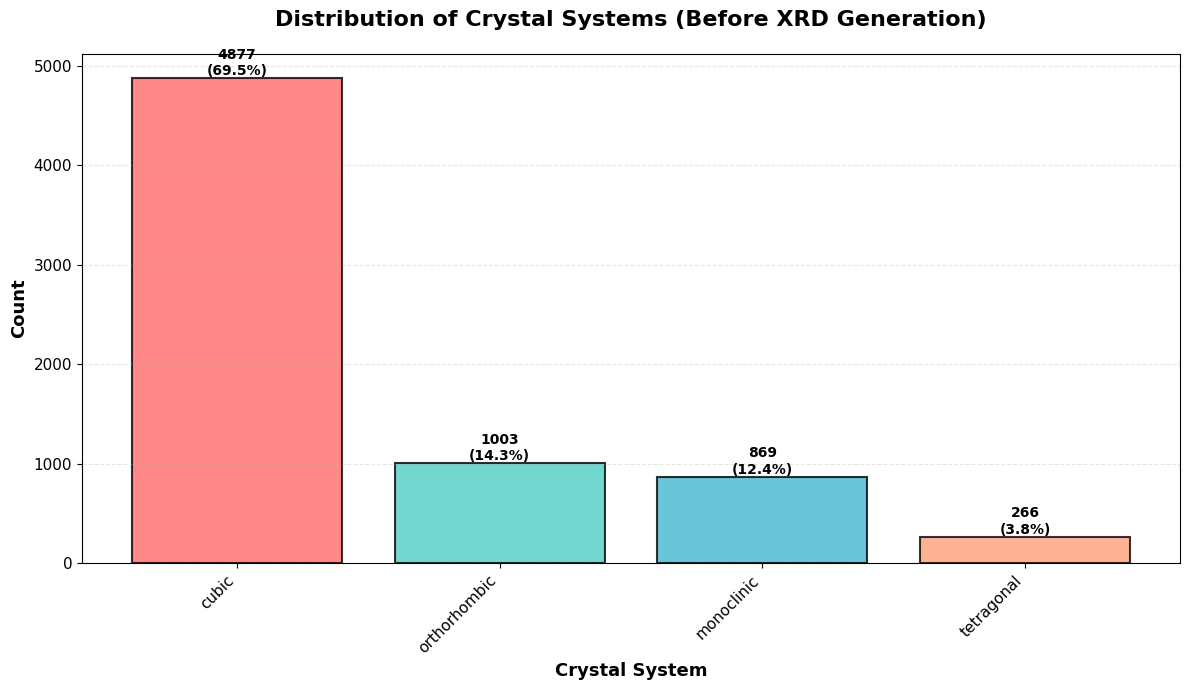

In [ ]:
# ============================================================================
# CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)
# ============================================================================

print("\n" + "="*70)
print("CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)")
print("="*70)

class_distribution = df_materials['crystal_system'].value_counts()
print("\nCount by Crystal System:")
print(class_distribution)

print("\nPercentage by Crystal System:")
class_distribution_pct = (class_distribution / len(df_materials) * 100).round(2)
for system, pct in class_distribution_pct.items():
    print(f"  {system.capitalize():<15}: {pct:>6.2f}%")

# Plot distribution
plt.figure(figsize=(12, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(class_distribution.index, class_distribution.values,
               color=colors[:len(class_distribution)],
               edgecolor='black', linewidth=1.5, alpha=0.8)

plt.title('Distribution of Crystal Systems (Before XRD Generation)',
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Crystal System', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df_materials)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# XRD PATTERN GENERATION
# ============================================================================

def generate_xrd_patterns(df_materials, two_theta_min=TWO_THETA_MIN,
                         two_theta_max=TWO_THETA_MAX, n_points=N_POINTS):
    """Generate XRD patterns from structures"""

    two_theta_grid = np.linspace(two_theta_min, two_theta_max, n_points)
    X_patterns = []
    y_systems = []
    material_ids = []  # Store material IDs
    formulas = []  # Store formulas
    valid_indices = []
    failed_count = 0

    xrd_calc = XRDCalculator(wavelength="CuKa")

    print("="*70)
    print("GENERATING XRD PATTERNS")
    print("="*70)
    print(f"2θ range: {two_theta_min}° - {two_theta_max}°")
    print(f"Number of points: {n_points}")
    print(f"Wavelength: Cu Kα")
    print()

    total = len(df_materials)

    for idx, row in df_materials.iterrows():
        try:
            structure = row['structure']
            pattern = xrd_calc.get_pattern(
                structure,
                two_theta_range=(two_theta_min, two_theta_max),
            )
            intensities = np.interp(two_theta_grid, pattern.x, pattern.y)

            X_patterns.append(intensities)
            y_systems.append(row['crystal_system'])
            material_ids.append(row['material_id'])
            formulas.append(row['formula'])
            valid_indices.append(idx)

        except Exception as e:
            failed_count += 1
            if failed_count <= 3:  # Only show first 3 errors
                print(f"✗ Error for {row['material_id']}: {str(e)[:50]}...")
            continue

        if (len(X_patterns) % 500) == 0:
            print(f"✓ Processed {len(X_patterns)}/{total} patterns... ({len(X_patterns)/total*100:.1f}%)")

    X_patterns = np.array(X_patterns, dtype=np.float32)
    y_systems = np.array(y_systems)
    material_ids = np.array(material_ids)
    formulas = np.array(formulas)

    print()
    print("="*70)
    print("XRD GENERATION SUMMARY")
    print("="*70)
    print(f"✓ Successfully generated: {len(X_patterns)} patterns")
    print(f"✗ Failed: {failed_count} patterns")
    print(f"Success rate: {len(X_patterns)/(len(X_patterns)+failed_count)*100:.2f}%")
    print(f"Pattern shape: {X_patterns.shape}")
    print(f"Crystal system distribution:\n{Counter(y_systems)}")

    return two_theta_grid, X_patterns, y_systems, material_ids, formulas, valid_indices

# Generate XRD patterns
two_theta_grid, X_raw, y_str, material_ids, formulas, valid_idx = generate_xrd_patterns(df_materials)

# Update dataframe to keep only valid materials
df_materials = df_materials.iloc[valid_idx].reset_index(drop=True)

print(f"\n✓ Final dataset size: {len(X_raw)} samples")

GENERATING XRD PATTERNS
2θ range: 10° - 110°
Number of points: 2048
Wavelength: Cu Kα

✓ Processed 500/7015 patterns... (7.1%)
✓ Processed 1000/7015 patterns... (14.3%)
✓ Processed 1500/7015 patterns... (21.4%)
✓ Processed 2000/7015 patterns... (28.5%)
✓ Processed 2500/7015 patterns... (35.6%)
✓ Processed 3000/7015 patterns... (42.8%)
✓ Processed 3500/7015 patterns... (49.9%)
✓ Processed 4000/7015 patterns... (57.0%)
✓ Processed 4500/7015 patterns... (64.1%)
✓ Processed 5000/7015 patterns... (71.3%)
✓ Processed 5500/7015 patterns... (78.4%)
✓ Processed 6000/7015 patterns... (85.5%)
✓ Processed 6500/7015 patterns... (92.7%)
✓ Processed 7000/7015 patterns... (99.8%)

XRD GENERATION SUMMARY
✓ Successfully generated: 7015 patterns
✗ Failed: 0 patterns
Success rate: 100.00%
Pattern shape: (7015, 2048)
Crystal system distribution:
Counter({np.str_('cubic'): 4877, np.str_('orthorhombic'): 1003, np.str_('monoclinic'): 869, np.str_('tetragonal'): 266})

✓ Final dataset size: 7015 samples



XRD PATTERN VISUALIZATION (WITH FORMULA)
Displaying 1 sample per crystal system (sorted by 2θ)
Plotting Cubic: 4877 samples available
Plotting Monoclinic: 869 samples available
Plotting Orthorhombic: 1003 samples available
Plotting Tetragonal: 266 samples available


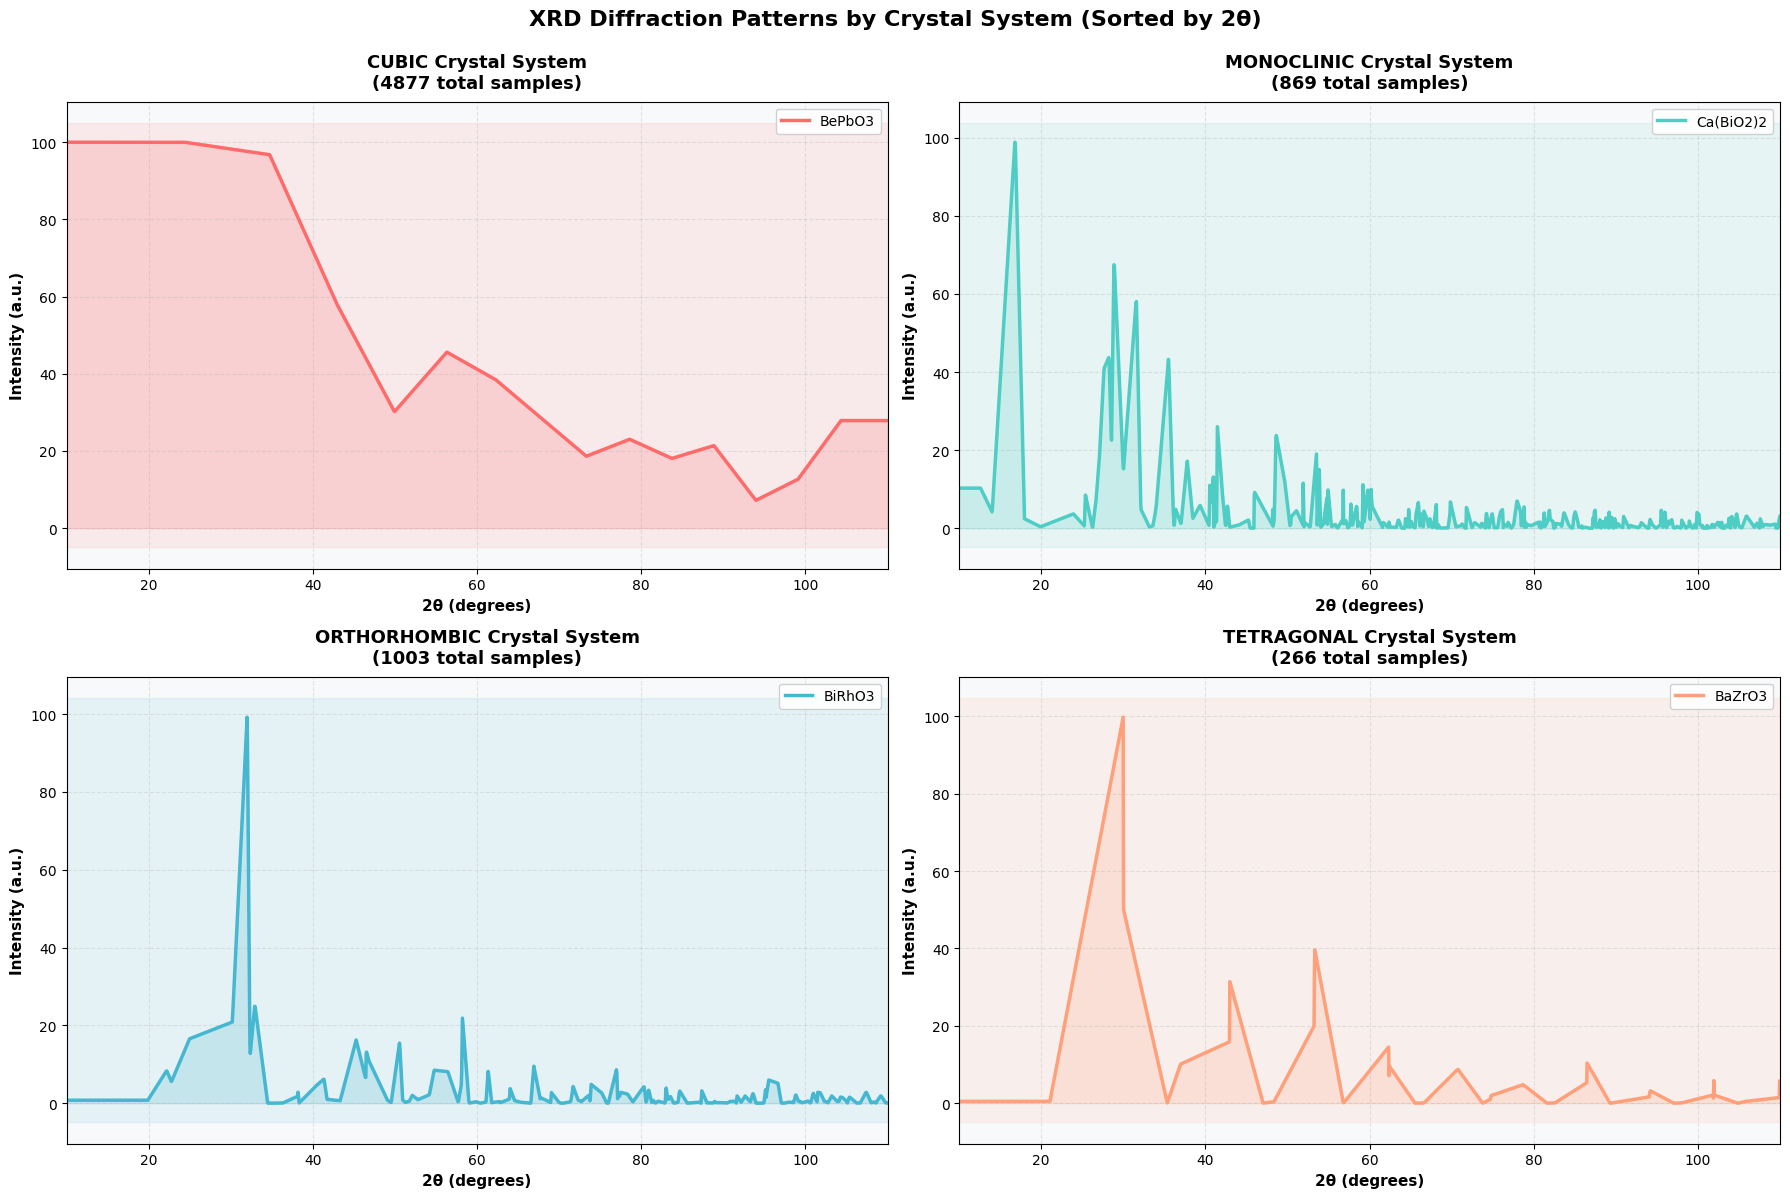


✓ XRD patterns visualization complete!
✓ Each pattern shows chemical formula


In [ ]:
# ============================================================================
# XRD PATTERN VISUALIZATION (WITH FORMULA ONLY)
# ============================================================================

print("\n" + "="*70)
print("XRD PATTERN VISUALIZATION (WITH FORMULA)")
print("="*70)
print("Displaying 1 sample per crystal system (sorted by 2θ)")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

colors_map = {
    'cubic': '#FF6B6B',
    'monoclinic': '#4ECDC4',
    'orthorhombic': '#45B7D1',
    'tetragonal': '#FFA07A'
}

for idx, system in enumerate(TARGET_SYSTEMS):
    ax = axes[idx]

    # Get indices for this system
    system_indices = np.where(y_str == system)[0]

    print(f"Plotting {system.capitalize()}: {len(system_indices)} samples available")

    if len(system_indices) > 0:
        # Take only 1 sample (first sample)
        sample_idx = system_indices[0]

        # Get formula
        formula = formulas[sample_idx]

        # Get pattern data
        pattern_data = X_raw[sample_idx]

        # Sort by 2θ (should already be sorted, but ensuring)
        sorted_indices = np.argsort(two_theta_grid)
        two_theta_sorted = two_theta_grid[sorted_indices]
        pattern_sorted = pattern_data[sorted_indices]

        # Plot the sorted pattern
        ax.plot(two_theta_sorted, pattern_sorted,
               linewidth=2.5,
               color=colors_map[system],
               label=f'{formula}')

        # Fill under the curve for better visualization
        ax.fill_between(two_theta_sorted, pattern_sorted,
                        alpha=0.2, color=colors_map[system])

    ax.set_title(f'{system.upper()} Crystal System\n({len(system_indices)} total samples)',
                fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel('2θ (degrees)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Intensity (a.u.)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')

    # Add subtle background color
    ax.axhspan(ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color=colors_map[system])

    # Set x-axis limits
    ax.set_xlim(TWO_THETA_MIN, TWO_THETA_MAX)

plt.suptitle('XRD Diffraction Patterns by Crystal System (Sorted by 2θ)',
            fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ XRD patterns visualization complete!")
print("✓ Each pattern shows chemical formula")

In [ ]:
# ============================================================================
# DATA PREPARATION: ENCODING & SPLITTING (70:10:20)
# ============================================================================

print("\n" + "="*70)
print("DATA PREPARATION: ENCODING & SPLITTING")
print("="*70)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_str)
class_names = list(le.classes_)

print("\nClass Encoding Mapping:")
for i, name in enumerate(class_names):
    count = np.sum(y_encoded == i)
    print(f"  {i} → {name.capitalize():<15} ({count} samples)")

# Split data: 70% train, 10% validation, 20% test
# First split: 80% (train+val), 20% test
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

# Second split: 70% train, 10% validation (from the 80%)
# 10/80 = 0.125
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=SEED,
    stratify=y_temp
)

print("\n" + "-"*70)
print("DATA SPLIT (70% Train / 10% Validation / 20% Test)")
print("-"*70)
print(f"Training set size:     {len(X_train_raw):>6} samples ({len(X_train_raw)/len(X_raw)*100:.1f}%)")
print(f"Validation set size:   {len(X_val_raw):>6} samples ({len(X_val_raw)/len(X_raw)*100:.1f}%)")
print(f"Test set size:         {len(X_test_raw):>6} samples ({len(X_test_raw)/len(X_raw)*100:.1f}%)")
print(f"Total:                 {len(X_raw):>6} samples")

print("\nTraining Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_train)*100:>5.1f}%)")

print("\nValidation Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_val == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_val)*100:>5.1f}%)")

print("\nTest Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_test)*100:>5.1f}%)")


DATA PREPARATION: ENCODING & SPLITTING

Class Encoding Mapping:
  0 → Cubic           (4877 samples)
  1 → Monoclinic      (869 samples)
  2 → Orthorhombic    (1003 samples)
  3 → Tetragonal      (266 samples)

----------------------------------------------------------------------
DATA SPLIT (70% Train / 10% Validation / 20% Test)
----------------------------------------------------------------------
Training set size:       4910 samples (70.0%)
Validation set size:      702 samples (10.0%)
Test set size:           1403 samples (20.0%)
Total:                   7015 samples

Training Set Distribution:
  Cubic          :  3414 samples ( 69.5%)
  Monoclinic     :   608 samples ( 12.4%)
  Orthorhombic   :   702 samples ( 14.3%)
  Tetragonal     :   186 samples (  3.8%)

Validation Set Distribution:
  Cubic          :   488 samples ( 69.5%)
  Monoclinic     :    87 samples ( 12.4%)
  Orthorhombic   :   100 samples ( 14.2%)
  Tetragonal     :    27 samples (  3.8%)

Test Set Distribution:
 

In [ ]:
# ============================================================================
# APPLYING SMOTE WITH CUSTOM RATIO (Ortho:10%, Mono:20%, Tetra:20%)
# ============================================================================

print("\n" + "="*70)
print("APPLYING SMOTE WITH CUSTOM AUGMENTATION RATIO")
print("="*70)
print("Augmentation Strategy:")
print("  • Orthorhombic: +20% of current count")
print("  • Monoclinic:   +20% of current count")
print("  • Tetragonal:   +30% of current count")
print("  • Cubic:        No augmentation (majority class)")
print()

print("BEFORE SMOTE:")
print("-" * 50)
print(f"Training samples: {len(X_train_raw)}")
print("\nClass distribution:")

# Calculate current counts and target counts
sampling_strategy = {}
for i, name in enumerate(class_names):
    current_count = np.sum(y_train == i)

    # Define augmentation ratio based on class
    if name == 'orthorhombic':
        target_count = int(current_count * 1.10)  # +20%
        augmentation_pct = 10
    elif name == 'monoclinic':
        target_count = int(current_count * 1.30)  # +20%
        augmentation_pct = 30
    elif name == 'tetragonal':
        target_count = int(current_count * 4.00)  # +30%
        augmentation_pct = 300
    else:  # cubic
        target_count = current_count  # No augmentation
        augmentation_pct = 0

    sampling_strategy[i] = target_count

    print(f"  {name.capitalize():<15}: {current_count:>5} samples → Target: {target_count:>5} (+{augmentation_pct}%)")

# Apply SMOTE with custom sampling strategy
smote = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=5, random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train)

print("\n" + "="*70)
print("AFTER SMOTE:")
print("-" * 50)
print(f"Training samples: {len(X_train_smote)} (increased by {len(X_train_smote) - len(X_train_raw)})")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train_smote == i)
    original_count = np.sum(y_train == i)
    increase = count - original_count
    increase_pct = (increase / original_count * 100) if original_count > 0 else 0
    print(f"  {name.capitalize():<15}: {count:>5} samples (Original: {original_count}, +{increase} = +{increase_pct:.1f}%)")

print("\n" + "="*70)
print("VALIDATION SET (UNCHANGED - NO OVERSAMPLING):")
print("-" * 50)
print(f"Validation samples: {len(X_val_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_val == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n" + "="*70)
print("TEST SET (UNCHANGED - NO OVERSAMPLING):")
print("-" * 50)
print(f"Test samples: {len(X_test_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n✓ SMOTE oversampling applied successfully!")
print(f"✓ Custom augmentation ratio applied: Ortho(+20%), Mono(+20%), Tetra(+30%), Cubic(+0%)")


APPLYING SMOTE WITH CUSTOM AUGMENTATION RATIO
Augmentation Strategy:
  • Orthorhombic: +20% of current count
  • Monoclinic:   +20% of current count
  • Tetragonal:   +30% of current count
  • Cubic:        No augmentation (majority class)

BEFORE SMOTE:
--------------------------------------------------
Training samples: 4910

Class distribution:
  Cubic          :  3414 samples → Target:  3414 (+0%)
  Monoclinic     :   608 samples → Target:   790 (+30%)
  Orthorhombic   :   702 samples → Target:   772 (+10%)
  Tetragonal     :   186 samples → Target:   744 (+300%)

AFTER SMOTE:
--------------------------------------------------
Training samples: 5720 (increased by 810)

Class distribution:
  Cubic          :  3414 samples (Original: 3414, +0 = +0.0%)
  Monoclinic     :   790 samples (Original: 608, +182 = +29.9%)
  Orthorhombic   :   772 samples (Original: 702, +70 = +10.0%)
  Tetragonal     :   744 samples (Original: 186, +558 = +300.0%)

VALIDATION SET (UNCHANGED - NO OVERSAMPLIN

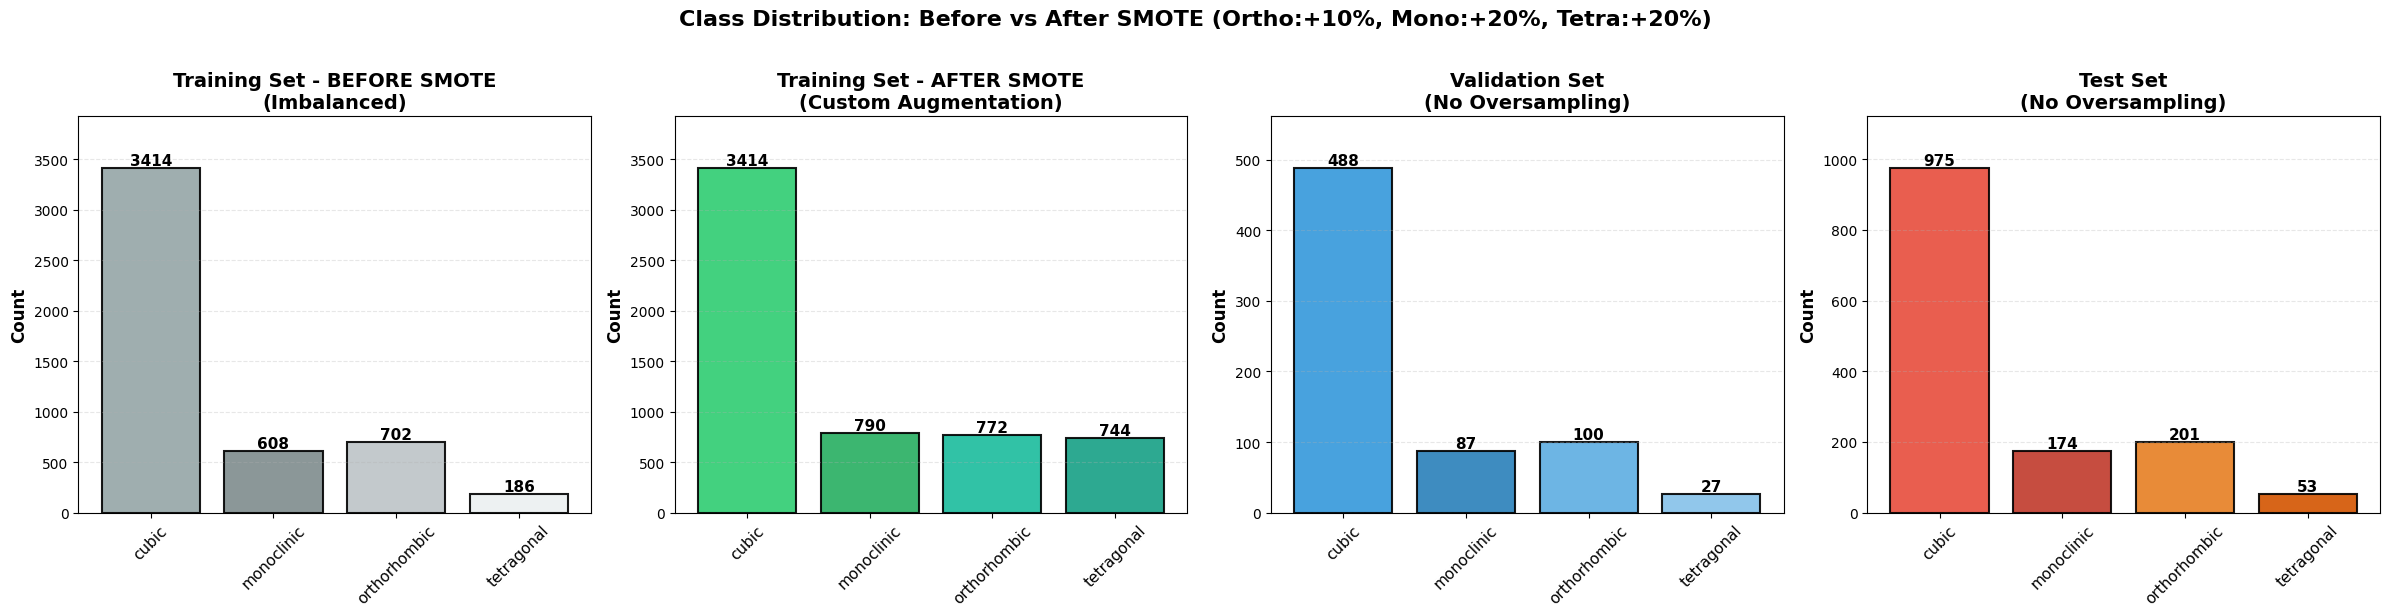

In [ ]:
# ============================================================================
# VISUALIZE CLASS DISTRIBUTION COMPARISON
# ============================================================================

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Color palettes
colors_before = ['#95a5a6', '#7f8c8d', '#bdc3c7', '#ecf0f1']
colors_after = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085']
colors_val = ['#3498db', '#2980b9', '#5dade2', '#85c1e9']
colors_test = ['#e74c3c', '#c0392b', '#e67e22', '#d35400']

# Plot 1: Training Before SMOTE
unique, counts = np.unique(y_train, return_counts=True)
labels = [class_names[i] for i in unique]
bars1 = axes[0].bar(labels, counts, color=colors_before, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[0].set_title('Training Set - BEFORE SMOTE\n(Imbalanced)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars1, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Training After SMOTE
unique, counts = np.unique(y_train_smote, return_counts=True)
labels = [class_names[i] for i in unique]
bars2 = axes[1].bar(labels, counts, color=colors_after, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[1].set_title('Training Set - AFTER SMOTE\n(Custom Augmentation)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars2, counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 3: Validation Set
unique, counts = np.unique(y_val, return_counts=True)
labels = [class_names[i] for i in unique]
bars3 = axes[2].bar(labels, counts, color=colors_val, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[2].set_title('Validation Set\n(No Oversampling)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=11)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars3, counts):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 4: Test Set
unique, counts = np.unique(y_test, return_counts=True)
labels = [class_names[i] for i in unique]
bars4 = axes[3].bar(labels, counts, color=colors_test, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[3].set_title('Test Set\n(No Oversampling)', fontweight='bold', fontsize=14)
axes[3].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[3].tick_params(axis='x', rotation=45, labelsize=11)
axes[3].grid(axis='y', alpha=0.3, linestyle='--')
axes[3].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars4, counts):
    height = bar.get_height()
    axes[3].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Class Distribution: Before vs After SMOTE (Ortho:+10%, Mono:+20%, Tetra:+20%)',
            fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("SAMPLE COUNTS SUMMARY TABLE")
print("="*70)

summary_data = []
total_train_before = 0
total_train_after = 0
total_val = 0
total_test = 0

for i, system in enumerate(class_names):
    train_before = np.sum(y_train == i)
    train_after = np.sum(y_train_smote == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)

    total_train_before += train_before
    total_train_after += train_after
    total_val += val_count
    total_test += test_count

    increase = train_after - train_before
    increase_pct = (increase / train_before * 100) if train_before > 0 else 0

    summary_data.append({
        'Crystal System': system.capitalize(),
        'Train (Before)': train_before,
        'Train (After)': train_after,
        'Increase': f'+{increase}',
        'Increase %': f'+{increase_pct:.1f}%',
        'Validation': val_count,
        'Test': test_count
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "-"*70)
print(f"{'TOTAL':<20} {total_train_before:>13} {total_train_after:>14} {f'+{total_train_after-total_train_before}':>10} {f'+{(total_train_after-total_train_before)/total_train_before*100:.1f}%':>12} {total_val:>12} {total_test:>6}")
print("="*70)

print(f"\n✓ SMOTE oversampling increased training samples by {(total_train_after - total_train_before) / total_train_before * 100:.1f}%")
print(f"✓ Custom augmentation: Orthorhombic(+10%), Monoclinic(+20%), Tetragonal(+20%), Cubic(+0%)")


SAMPLE COUNTS SUMMARY TABLE
Crystal System  Train (Before)  Train (After) Increase Increase %  Validation  Test
         Cubic            3414           3414       +0      +0.0%         488   975
    Monoclinic             608            790     +182     +29.9%          87   174
  Orthorhombic             702            772      +70     +10.0%         100   201
    Tetragonal             186            744     +558    +300.0%          27    53

----------------------------------------------------------------------
TOTAL                         4910           5720       +810       +16.5%          702   1403

✓ SMOTE oversampling increased training samples by 16.5%
✓ Custom augmentation: Orthorhombic(+10%), Monoclinic(+20%), Tetragonal(+20%), Cubic(+0%)


In [ ]:
# ============================================================================
# MODEL ARCHITECTURE DEFINITIONS
# ============================================================================

def build_cnn_fixed(input_shape, num_classes: int):
    """
    Build CNN with fixed architecture
    - 3 Conv1D layers: filters=80, kernel_size=[100, 80, 20], stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout
    """
    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: 80 filters, kernel_size=100, stride=5
    x = layers.Conv1D(filters=80, kernel_size=80, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: 80 filters, kernel_size=80, stride=5
    x = layers.Conv1D(filters=80, kernel_size=40, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: 40 filters, kernel_size=20, stride=5
    x = layers.Conv1D(filters=80, kernel_size=20, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)


    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(128, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(64, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_Fixed")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def build_cnn_woa(params, input_shape, num_classes):
    """
    Build CNN with WOA-optimized hyperparameters
    Architecture:
    - 4 Conv1D layers: all with kernel_size optimized, stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout

    WOA optimizes:
    - Number of filters for all 3 conv layers (same value)
    - Fully connected layer 1 units
    - Fully connected layer 2 units (feature layer)
    """
    num_filters = int(params[0])      # Filters for all 3 conv layers
    fc1_units = int(params[1])        # FC layer 1 units
    fc2_units = int(params[2])        # FC layer 2 units (feature layer)

    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: kernel_size=100, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=100, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: kernel_size=80, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=70, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: kernel_size=20, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=40, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Convolutional Layer 4: kernel_size=20, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=10, strides=5,
                      activation="relu", padding="same",
                      name="conv4")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool4")(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(fc1_units, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(fc2_units, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_WOA")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [ ]:
# ============================================================================
# PREPARE DATA FOR TRAINING
# ============================================================================

# Reshape data for CNN (add channel dimension)
X_train_no_smote = X_train_raw[..., np.newaxis]
X_train_with_smote = X_train_smote[..., np.newaxis]
X_val = X_val_raw[..., np.newaxis]
X_test = X_test_raw[..., np.newaxis]

print("\n" + "="*70)
print("DATA SHAPES FOR TRAINING")
print("="*70)
print(f"X_train (no SMOTE):   {X_train_no_smote.shape}")
print(f"X_train (with SMOTE): {X_train_with_smote.shape}")
print(f"X_val:                {X_val.shape}")
print(f"X_test:               {X_test.shape}")
print("\n✓ All data ready for training!")


DATA SHAPES FOR TRAINING
X_train (no SMOTE):   (4910, 2048, 1)
X_train (with SMOTE): (5720, 2048, 1)
X_val:                (702, 2048, 1)
X_test:               (1403, 2048, 1)

✓ All data ready for training!


In [ ]:
# ============================================================================
# TRAIN MODEL 1: CNN WITHOUT SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 1: CNN (WITHOUT SMOTE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=100, stride=5")
print("  - Conv2: 80 filters, kernel=80,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Training Data: WITHOUT SMOTE (Imbalanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_no_smote = build_cnn_fixed(X_train_no_smote.shape[1:], num_classes=len(class_names))
model_cnn_no_smote.summary()

# Train model WITHOUT early stopping
history_cnn_no_smote = model_cnn_no_smote.fit(
    X_train_no_smote, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN Model (No SMOTE) training complete!")


TRAINING MODEL 1: CNN (WITHOUT SMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=100, stride=5
  - Conv2: 80 filters, kernel=80,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Training Data: WITHOUT SMOTE (Imbalanced)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       256,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,764 (1.60 MB)

 Trainable params: 419,764 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7410 - loss: 0.6438 - val_accuracy: 0.8319 - val_loss: 0.4063
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8448 - loss: 0.3920 - val_accuracy: 0.8775 - val_loss: 0.3022
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8787 - loss: 0.3182 - val_accuracy: 0.8989 - val_loss: 0.2736
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8813 - loss: 0.2823 - val_accuracy: 0.9031 - val_loss: 0.2829
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8977 - loss: 0.2410 - val_accuracy: 0.9103 - val_loss: 0.2300
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8742 - loss: 0.4643 - val_accuracy: 0.8932 - val_loss: 0.2923
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8976 - loss: 0.2635 - val_accuracy: 0.8989 - val_loss: 0.2764
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9132 - loss: 0.2251 - val_accuracy: 

In [ ]:
# ============================================================================
# TRAIN MODEL 2: CNN WITH SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 2: CNN (WITH SMOTE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=100, stride=5")
print("  - Conv2: 80 filters, kernel=80,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Training Data: WITH SMOTE (Custom Augmentation)")
print("• Augmentation: Ortho(+10%), Mono(+20%), Tetra(+20%), Cubic(+0%)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_with_smote = build_cnn_fixed(X_train_with_smote.shape[1:], num_classes=len(class_names))
model_cnn_with_smote.summary()

# Train model WITHOUT early stopping
history_cnn_with_smote = model_cnn_with_smote.fit(
    X_train_with_smote, y_train_smote,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN Model (With SMOTE) training complete!")


TRAINING MODEL 2: CNN (WITH SMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=100, stride=5
  - Conv2: 80 filters, kernel=80,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Training Data: WITH SMOTE (Custom Augmentation)
• Augmentation: Ortho(+10%), Mono(+20%), Tetra(+20%), Cubic(+0%)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       256,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,764 (1.60 MB)

 Trainable params: 419,764 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6582 - loss: 0.8067 - val_accuracy: 0.8205 - val_loss: 0.4977
Epoch 2/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8029 - loss: 0.4779 - val_accuracy: 0.8604 - val_loss: 0.3292
Epoch 3/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8655 - loss: 0.3433 - val_accuracy: 0.8761 - val_loss: 0.2688
Epoch 4/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8930 - loss: 0.2810 - val_accuracy: 0.9103 - val_loss: 0.3311
Epoch 5/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9101 - loss: 0.2341 - val_accuracy: 0.8960 - val_loss: 0.2874
Epoch 6/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9272 - loss: 0.2022 - val_accuracy: 0.8960 - val_loss: 0.3258
Epoch 7/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9327 - loss: 0.2035 - val_accuracy: 0.9046 - val_loss: 0.3440
Epoch 8/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9438 - loss: 0.1517 - val_accuracy: 0

In [ ]:
# ============================================================================
# EVALUATE ALL MODELS
# ============================================================================

# Predictions
y_pred_cnn_no_smote = np.argmax(model_cnn_no_smote.predict(X_test, verbose=0), axis=1)
y_pred_cnn_with_smote = np.argmax(model_cnn_with_smote.predict(X_test, verbose=0), axis=1)


# Calculate metrics for all models
models_results = {}

for model_name, y_pred in [
    ("CNN (No SMOTE)", y_pred_cnn_no_smote),
    ("CNN (With SMOTE)", y_pred_cnn_with_smote)
]:
    models_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average="macro", zero_division=0),
        'recall': recall_score(y_test, y_pred, average="macro", zero_division=0),
        'f1': f1_score(y_test, y_pred, average="macro", zero_division=0),
        'predictions': y_pred
    }

# Display results
print("\n" + "="*70)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*70)

comparison_df = pd.DataFrame(models_results).T
comparison_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Predictions']
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

print(comparison_df.to_string())

# Highlight best performers
print("\n" + "-"*70)
print("BEST PERFORMERS:")
print("-"*70)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric:<12}: {best_model:<25} ({best_value:.4f})")


MODEL COMPARISON - TEST SET PERFORMANCE
                  Accuracy Precision    Recall  F1-Score
CNN (No SMOTE)    0.902352  0.776385  0.698843  0.728108
CNN (With SMOTE)  0.908767  0.759159  0.779443  0.768045

----------------------------------------------------------------------
BEST PERFORMERS:
----------------------------------------------------------------------
Accuracy    : CNN (With SMOTE)          (0.9088)
Precision   : CNN (No SMOTE)            (0.7764)
Recall      : CNN (With SMOTE)          (0.7794)
F1-Score    : CNN (With SMOTE)          (0.7680)


In [ ]:
# ============================================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================================

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for model_name, results in models_results.items():
    print(f"\n{model_name}:")
    print("-" * 70)
    print(classification_report(y_test, results['predictions'], target_names=class_names))


DETAILED CLASSIFICATION REPORTS

CNN (No SMOTE):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.95      1.00      0.97       975
  monoclinic       0.80      0.64      0.71       174
orthorhombic       0.79      0.82      0.80       201
  tetragonal       0.56      0.34      0.42        53

    accuracy                           0.90      1403
   macro avg       0.78      0.70      0.73      1403
weighted avg       0.89      0.90      0.90      1403


CNN (With SMOTE):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.98      0.97      0.98       975
  monoclinic       0.74      0.79      0.77       174
orthorhombic       0.83      0.79      0.81       201
  tetragonal       0.48      0.57      0.52        53

    accuracy                           0.91      1403
   macro avg       0.76     

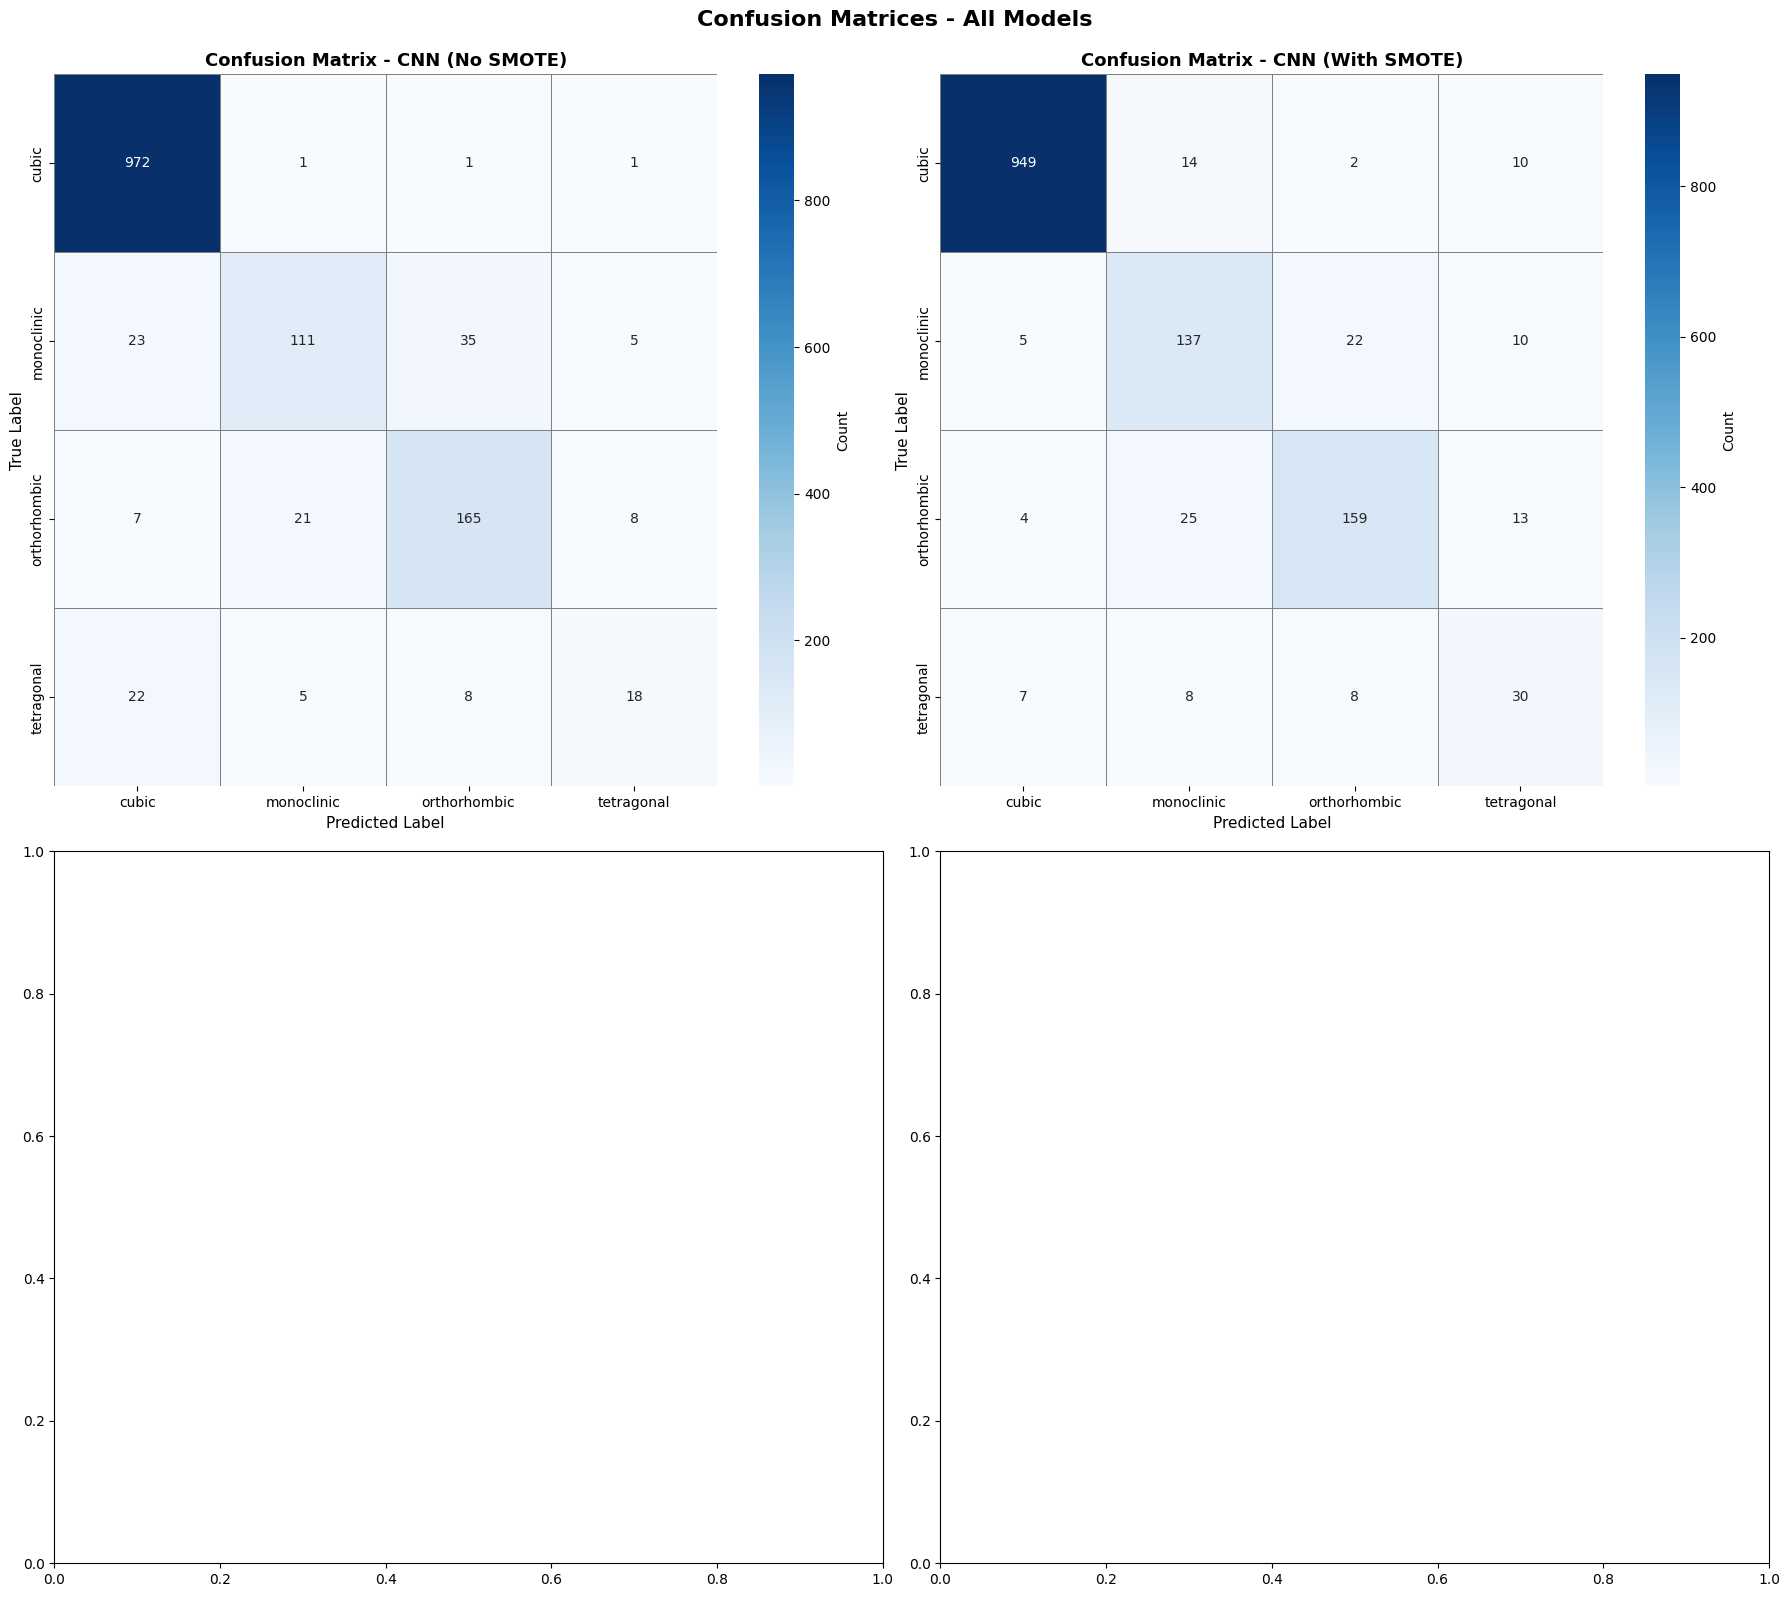

In [ ]:
# ============================================================================
# CONFUSION MATRICES
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(models_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray',
                ax=axes[idx])

    axes[idx].set_title(f'Confusion Matrix - {model_name}', fontweight='bold', fontsize=13)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    axes[idx].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices - All Models', fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# FEATURE EXTRACTION AND t-SNE VISUALIZATION
# ============================================================================

def extract_cnn_features(model, X_data):
    """Extract features from feature layer"""
    if len(X_data.shape) == 2:
        X_data = X_data[..., np.newaxis]
    feature_layer = model.get_layer("feature_layer")
    feat_model = Model(inputs=model.input, outputs=feature_layer.output)
    return feat_model.predict(X_data, verbose=0, batch_size=32)

print("\n" + "="*70)
print("EXTRACTING FEATURES FOR t-SNE VISUALIZATION")
print("="*70)

# Extract features from all models (using test data)
features_cnn_no_smote = extract_cnn_features(model_cnn_no_smote, X_test_raw)
features_cnn_with_smote = extract_cnn_features(model_cnn_with_smote, X_test_raw)


print("✓ Feature extraction complete for all models!")


EXTRACTING FEATURES FOR t-SNE VISUALIZATION
✓ Feature extraction complete for all models!


In [ ]:
# ============================================================================
# t-SNE VISUALIZATION FOR ALL MODELS
# ============================================================================

print("\n" + "="*70)
print("GENERATING t-SNE VISUALIZATIONS")
print("="*70)

# Apply t-SNE to all feature sets
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000, verbose=0)

print("Applying t-SNE to CNN (No SMOTE) features...")
X_tsne_cnn_no_smote = tsne.fit_transform(features_cnn_no_smote)

print("Applying t-SNE to CNN (With SMOTE) features...")
X_tsne_cnn_with_smote = tsne.fit_transform(features_cnn_with_smote)


print("✓ t-SNE transformation complete for all models!")


GENERATING t-SNE VISUALIZATIONS
Applying t-SNE to CNN (No SMOTE) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Applying t-SNE to CNN (With SMOTE) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ t-SNE transformation complete for all models!


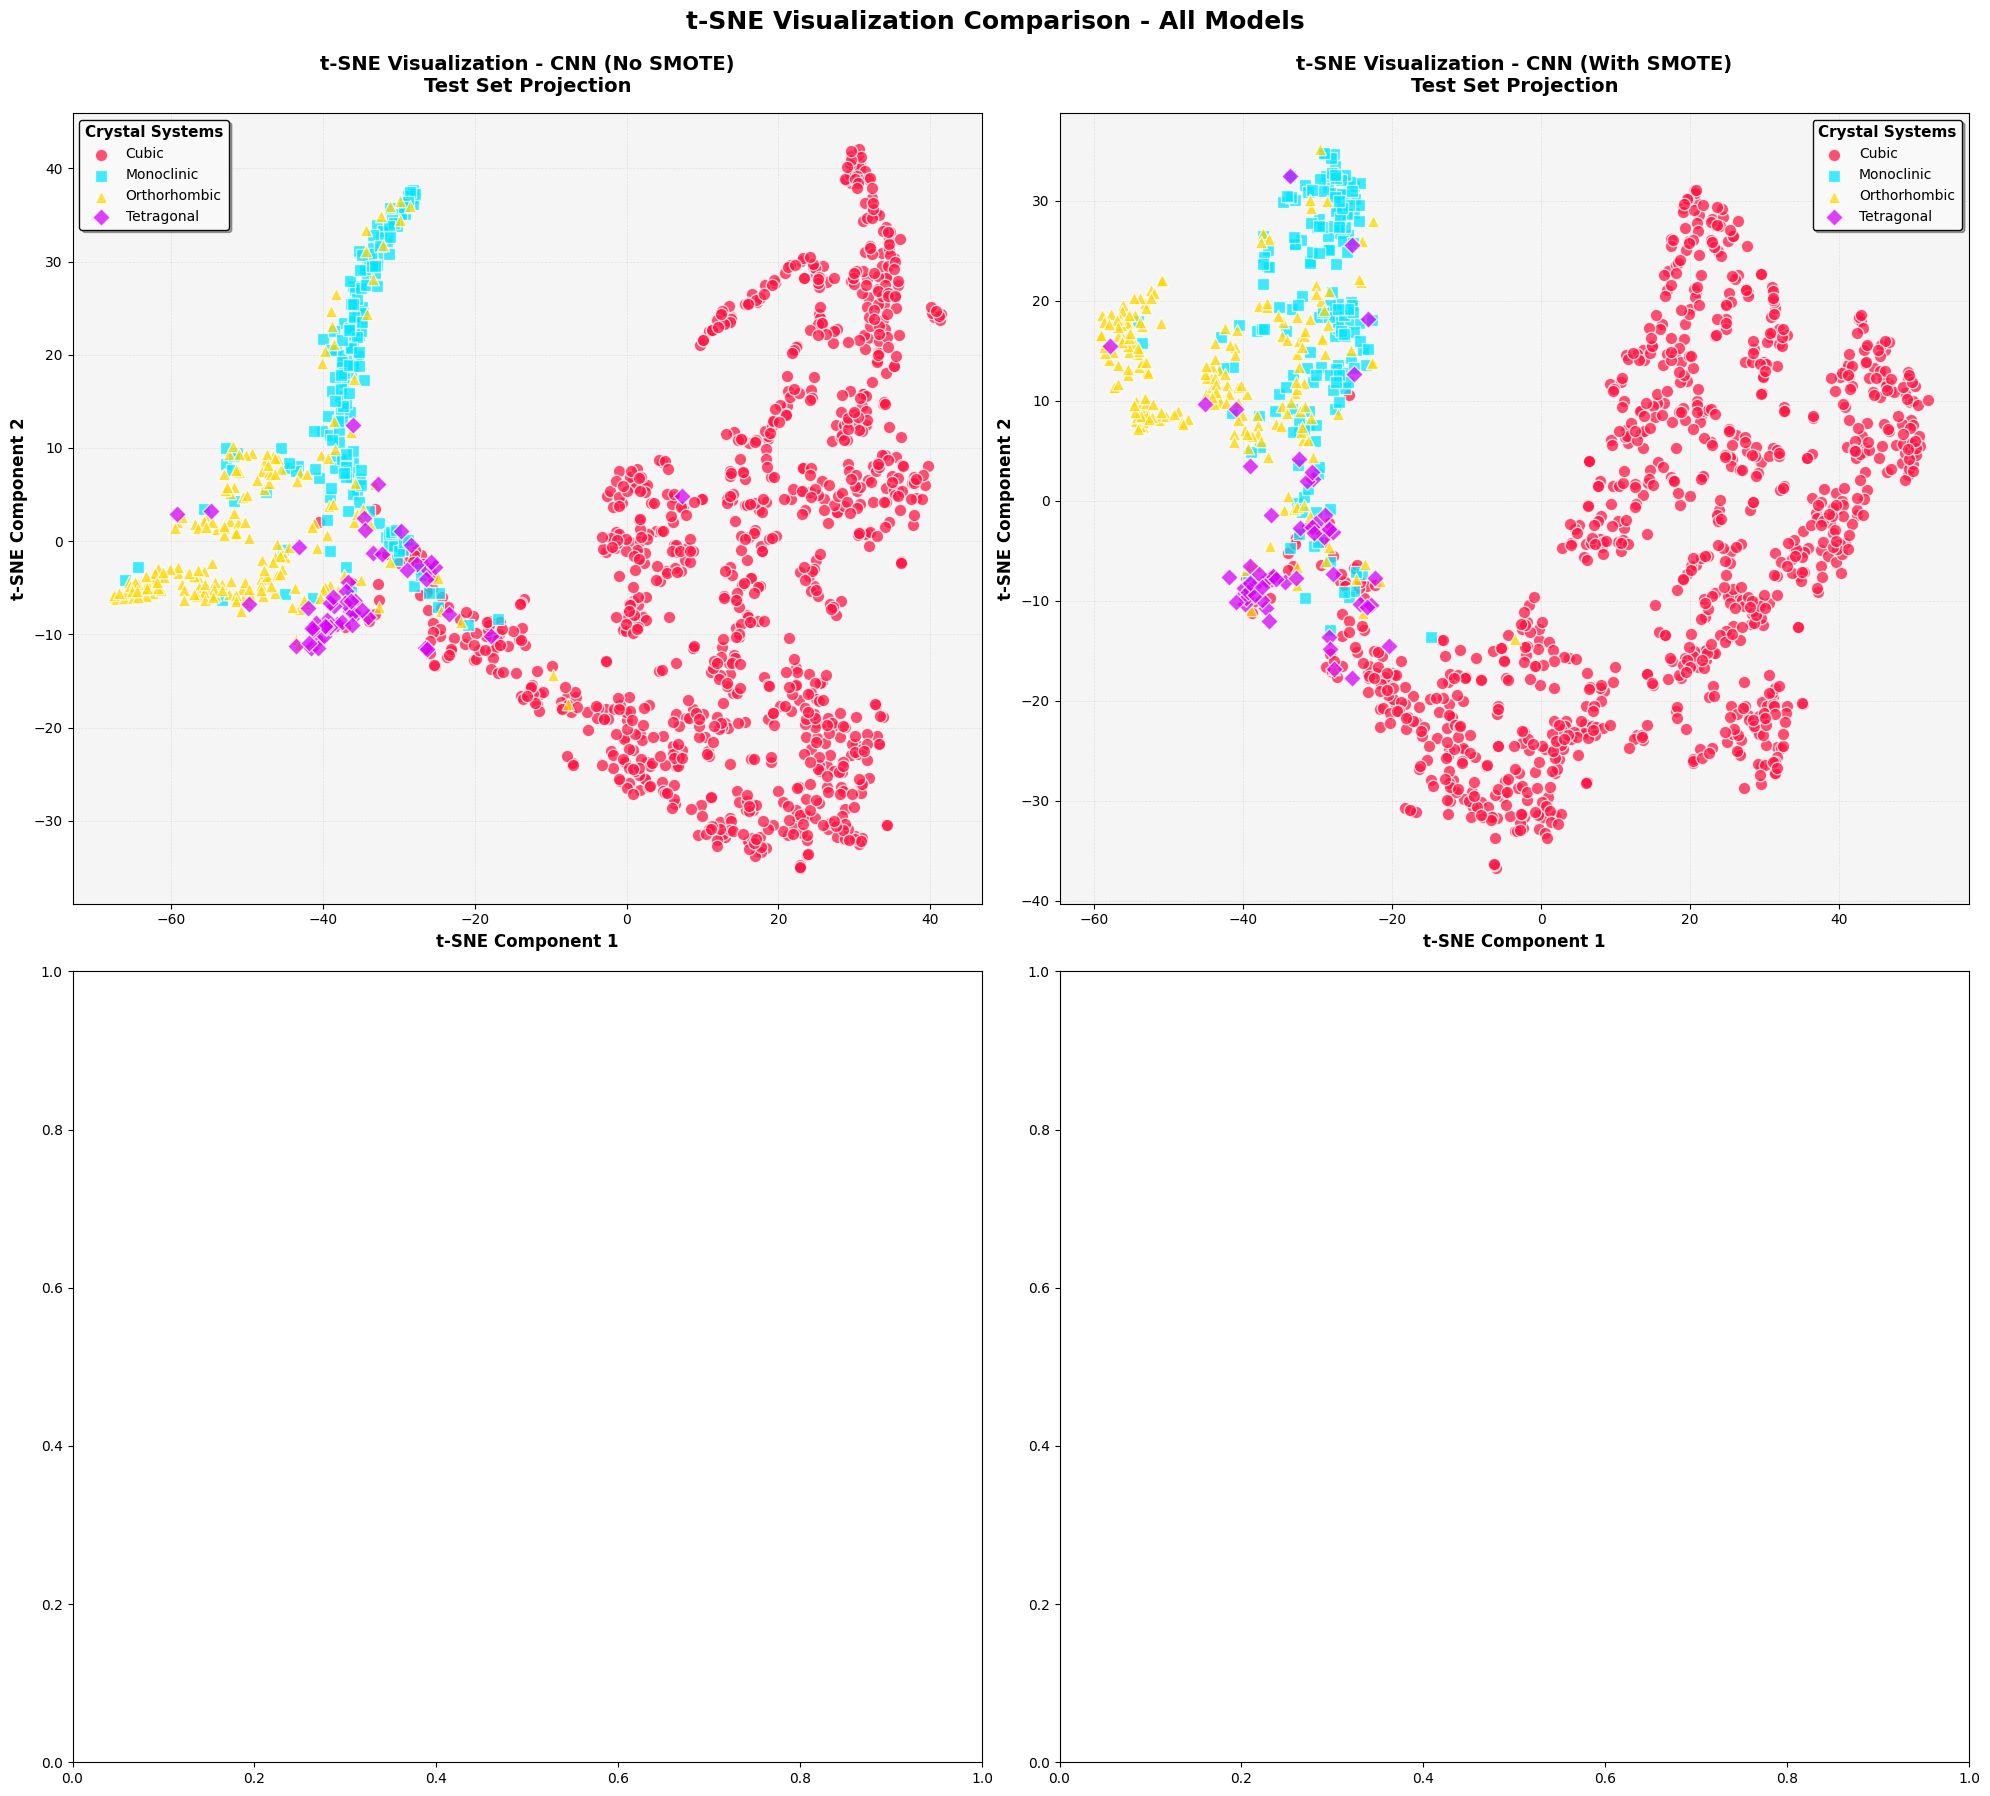


✓ t-SNE visualizations complete!
✓ Visualized 1403 test samples for each model


In [ ]:
# ============================================================================
# PLOT t-SNE VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.ravel()

# Bright and distinct color palette
colors_bright = [
    '#FF1744',  # Bright Red - Cubic
    '#00E5FF',  # Bright Cyan - Monoclinic
    '#FFD600',  # Bright Yellow - Orthorhombic
    '#D500F9'   # Bright Purple - Tetragonal
]

markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond

tsne_data = [
    (X_tsne_cnn_no_smote, "CNN (No SMOTE)"),
    (X_tsne_cnn_with_smote, "CNN (With SMOTE)")
]

for idx, (X_tsne, title) in enumerate(tsne_data):
    ax = axes[idx]

    for i, name in enumerate(class_names):
        mask = (y_test == i)
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=colors_bright[i],
                   label=name.capitalize(),
                   s=80,
                   alpha=0.75,
                   edgecolors='white',
                   linewidths=1.0,
                   marker=markers[i])

    ax.set_title(f't-SNE Visualization - {title}\nTest Set Projection',
                 fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')

    legend = ax.legend(fontsize=10, loc='best', framealpha=0.95,
                       edgecolor='black', fancybox=True, shadow=True)
    legend.set_title('Crystal Systems', prop={'size': 11, 'weight': 'bold'})

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_facecolor('#F5F5F5')

plt.suptitle('t-SNE Visualization Comparison - All Models',
            fontweight='bold', fontsize=18, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ t-SNE visualizations complete!")
print(f"✓ Visualized {len(X_test)} test samples for each model")